

Denne skabelon indeholder fire sektioner: **Opgave 1** til **Opgave 4**. Hver sektion har fire underspørgsmål: **Spørgsmål 1** til **Spørgsmål 4**.
En notebook konverteres til pdf ved at køre: jupyter nbconvert --to pdf ExamTemplate2026.ipynb i terminalen.
Når notebooken eksporteres/printes til PDF, starter hver ny opgave på en ny side.


<style>
@media print {
  .pagebreak { page-break-before: always; break-before: page; }
}
</style>


## Kopiérbar blok til indsættelse af billeder

### Markdown-metode
Kopiér linjen nedenfor til en Markdown-celle og ret filnavn/størrelse efter behov:

```markdown
<img src="images/dit_billede.png" alt="Kort beskrivelse" width="600">
```

### Python-metode
Kør kodecellen nedenfor, og brug funktionen `indsæt_billede(...)` i dine svar.


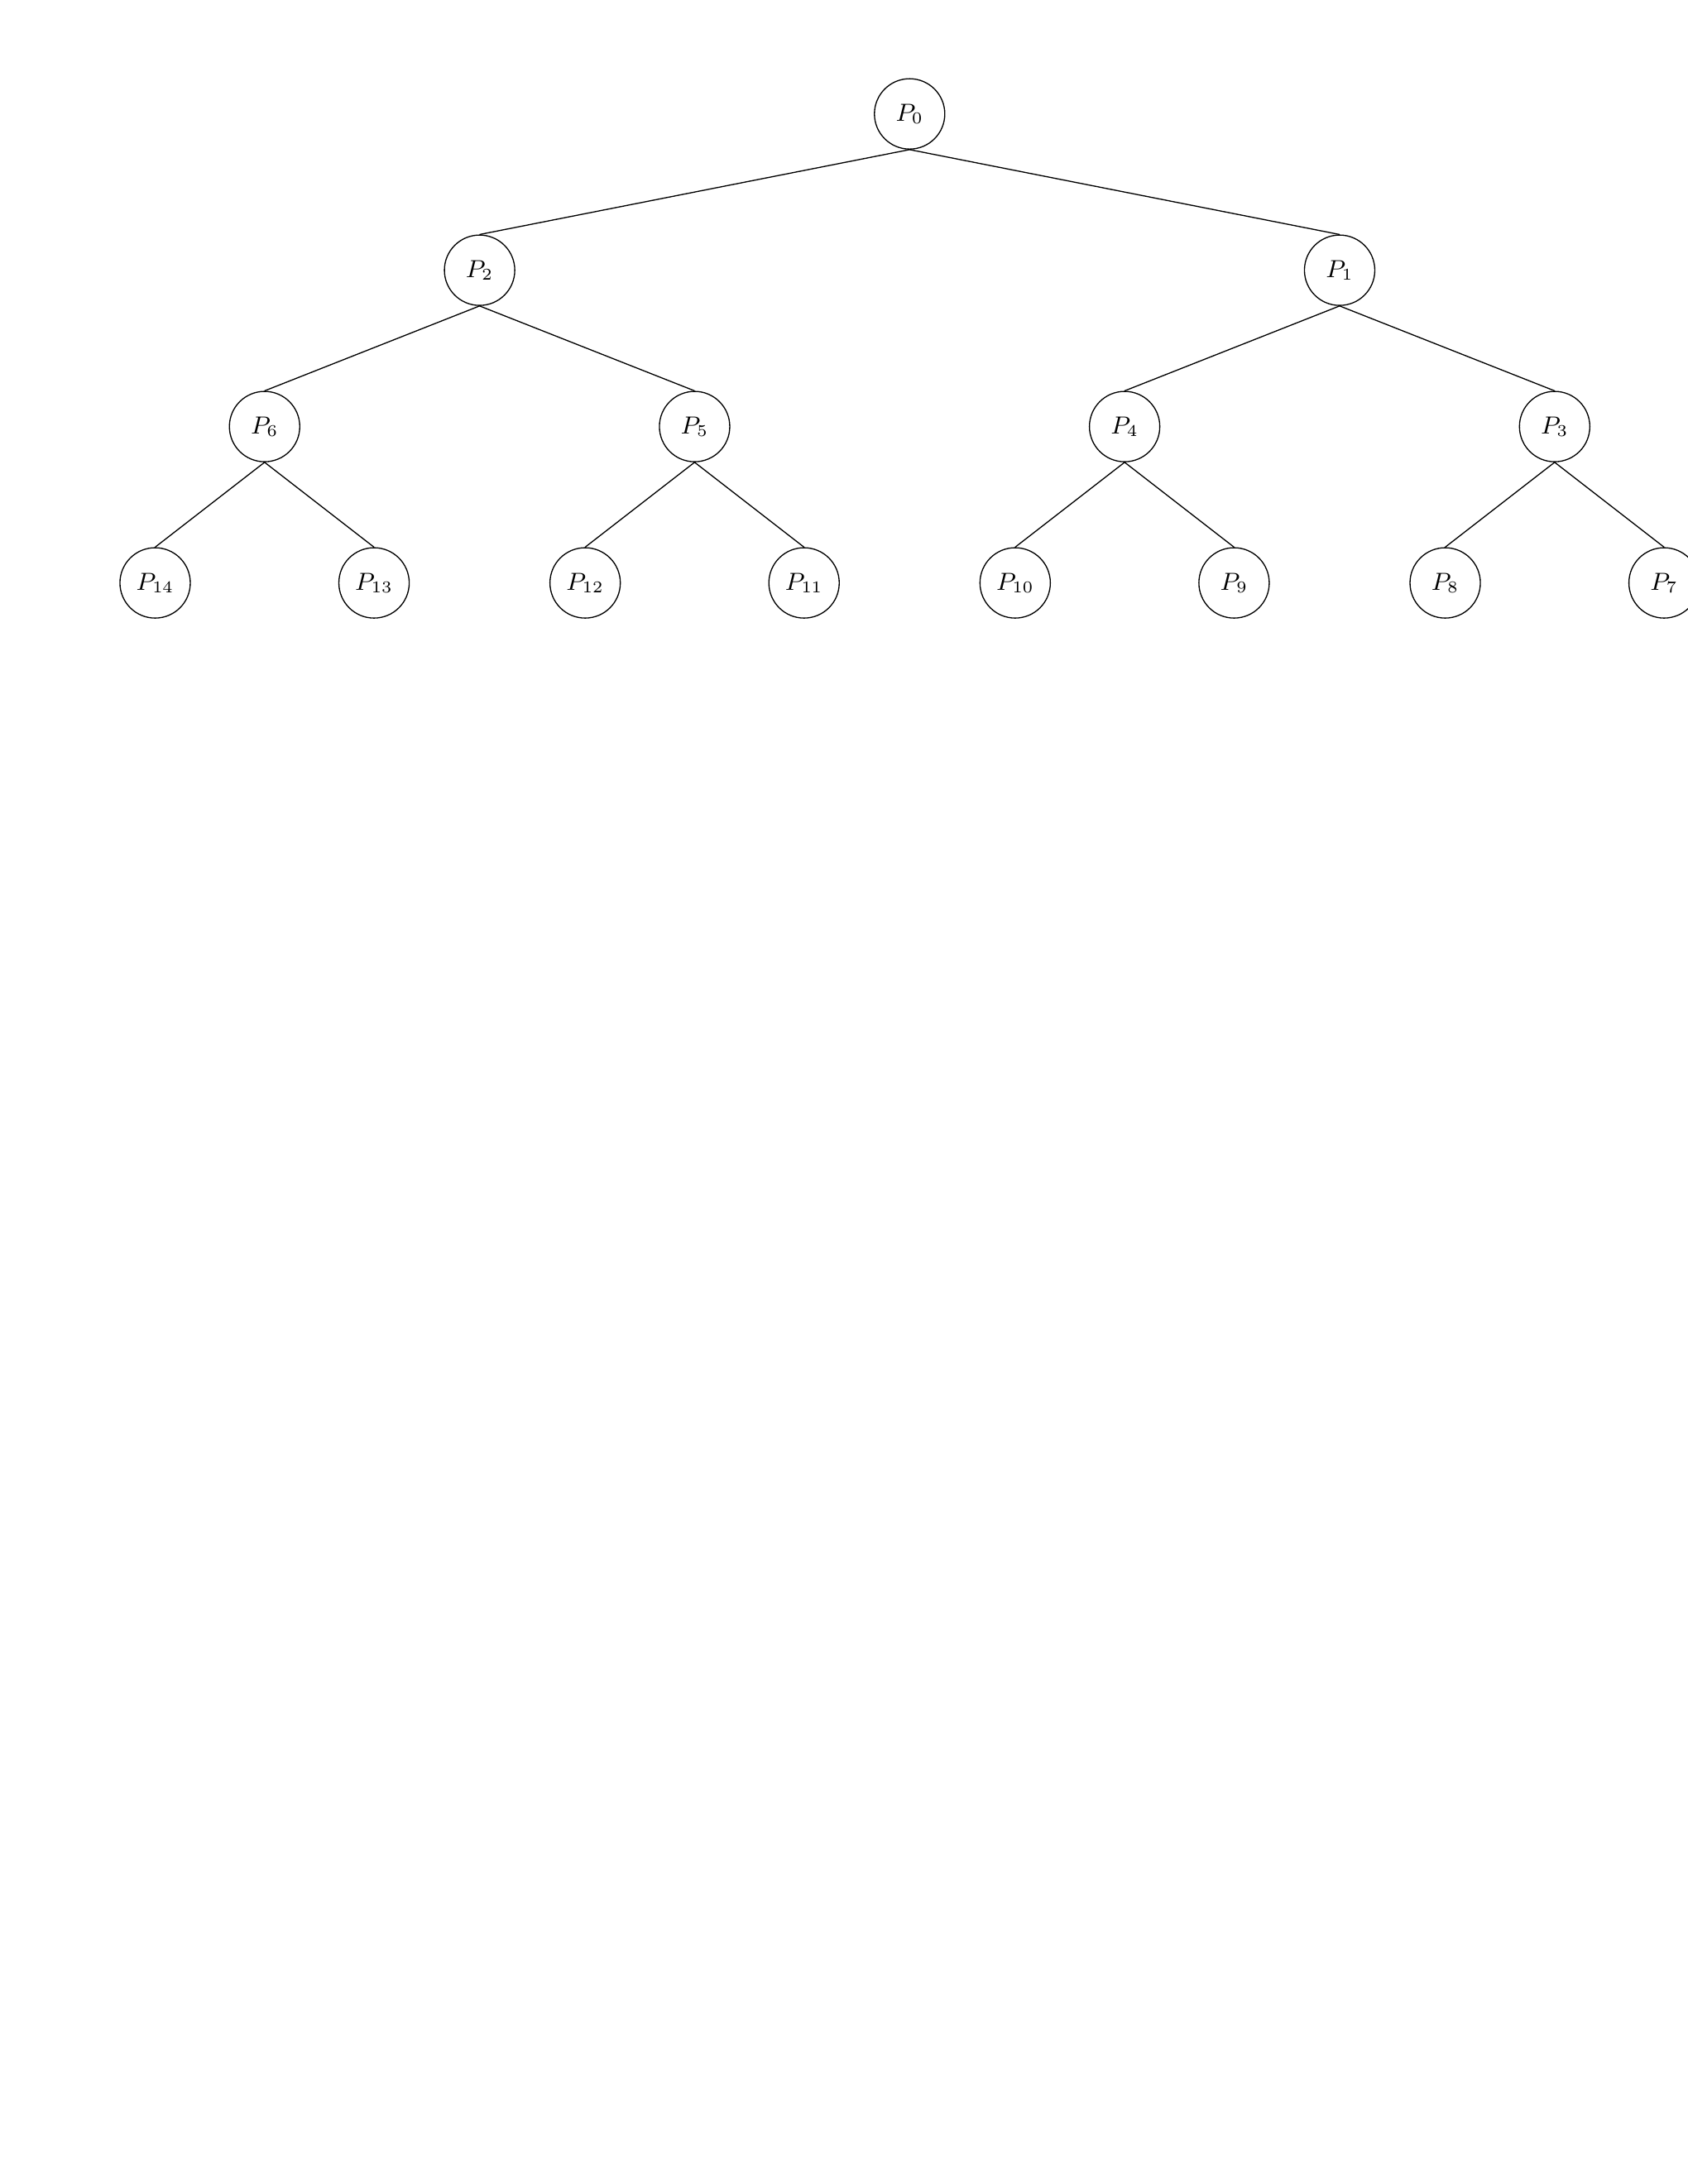

In [1]:
from IPython.display import Image, display

def indsæt_billede(sti, bredde=600):
    """Viser et billede i notebooken.

    Parametre:
    sti: Filsti til billedet, fx 'images/figur1.png'
    bredde: Billedets bredde i pixels, fx 600
    """
    display(Image(filename=sti, width=bredde))

indsæt_billede('tree.png', bredde=600)


In [2]:
# Imports
import numpy as np
import pulp as PLP

# Opgave 1

Skriv din besvarelse nedenfor.


In [3]:
from operator import eq

import numpy as np

class LPFeasibleRegionPlotter:
    def __init__(
        self,
        coef_matrix,
        rhs,
        equality_types,
        x1_bounds=(0, 20),
        x2_bounds=(0, 20),
        grid_points=400,
        tol=1e-9,
    ):


        """
        Plot feasible regions for 2-variable LP constraints.

        Args:
            coef_matrix: Iterable of [a, b] for each constraint a*x1 + b*x2 (shape: n x 2)
            rhs: Iterable of right-hand side values c (length: n)
            equality_types: Iterable of constraint types: "<=", "<", ">=", ">", "==", "="
            x1_bounds: (min, max) for x1 axis
            x2_bounds: (min, max) for x2 axis
            grid_points: Resolution for feasible-region raster
            tol: Numerical tolerance
        """
        self.coef_matrix = np.asarray(coef_matrix, dtype=float) if coef_matrix is not None else None
        self.rhs = np.asarray(rhs, dtype=float) if rhs is not None else None
        self.equality_types = list(equality_types) if equality_types is not None else None
        self.x1_bounds = tuple(x1_bounds)
        self.x2_bounds = tuple(x2_bounds)
        self.grid_points = int(grid_points)
        self.tol = float(tol)
        self.objective_coeffs = None
        self.objective_value = None




    def constraints_from_model(self, model):
        import pulp as PLP
        constraints = list(model.constraints.values())
        variables = model.variables()

        def format_sense(x):
            if x == 0:
                return "=="
            elif x == -1:
                return "<="
            elif x == 1:
                return ">="
            else:
                raise ValueError(f"Unknown constraint sense: {x}")

        coef_matrix = []
        rhs = []
        equality_types = []

        for constraint in constraints:
            rhs.append(-constraint.constant)
            equality_types.append(format_sense(constraint.sense))

            coef_matrix.append([
                constraint.expr.get(v, 0)
                for v in variables
            ])

        self.coef_matrix = np.array(coef_matrix)
        self.rhs = rhs
        self.equality_types = equality_types
        self.objective_coeffs = [model.objective.get(v, 0) for v in variables]
        model.solve()
        self.objective_value = PLP.value(model.objective)

    def _validate_inputs(self):
        if self.coef_matrix.ndim != 2 or self.coef_matrix.shape[1] != 2:
            raise ValueError("coef_matrix must have shape (n_constraints, 2).")

        n = self.coef_matrix.shape[0]
        if len(self.rhs) != n or len(self.equality_types) != n:
            raise ValueError(
                "Lengths must match: len(coef_matrix) == len(rhs) == len(equality_types)."
            )

        valid_eq = {"<=", "<", ">=", ">", "==", "="}
        bad = [e for e in self.equality_types if e not in valid_eq]
        if bad:
            raise ValueError(f"Invalid equality_types found: {bad}. Allowed: {sorted(valid_eq)}")

        if self.x1_bounds[0] >= self.x1_bounds[1]:
            raise ValueError("x1_bounds must satisfy min < max.")
        if self.x2_bounds[0] >= self.x2_bounds[1]:
            raise ValueError("x2_bounds must satisfy min < max.")
        if self.grid_points < 50:
            raise ValueError("grid_points should be at least 50 for decent visualization.")

    @staticmethod
    def _format_constraint_label(a, b, eq_type, c):
        def fmt_num(v):
            if abs(v - round(v)) < 1e-12:
                return str(int(round(v)))
            return f"{v:.3g}"

        parts = []
        if abs(a) > 1e-12:
            parts.append(f"{fmt_num(a)}$x_1$")
        if abs(b) > 1e-12:
            sign = "+" if b >= 0 and parts else ""
            parts.append(f"{sign}{fmt_num(b)}$x_2$")
        if not parts:
            lhs = "0"
        else:
            lhs = " ".join(parts)

        return f"{lhs} {eq_type} {fmt_num(c)}"

    def _constraint_line(self, a, b, c, x_vals):
        """
        Returns x2 values for line a*x1 + b*x2 = c if non-vertical.
        For vertical lines, caller should use x = c/a.
        """
        return (c - a * x_vals) / b

    def plot(
        self,
        objective_coeffs=None,
        optimal_value=None,
        show_constraints=True,
        show_feasible_region=True,
        show_objective=True,
        show_equality_bands=False,
        equality_band_tol=None,
        ax=None,
        title="Feasible Region",
        legend=True,
        show = True
    ):
        import matplotlib.pyplot as plt
        """
        Create the LP feasible region plot and return (fig, ax) for post-editing.

        Args:
            objective_coeffs: (c1, c2) for objective c1*x1 + c2*x2
            optimal_value: scalar Z value to plot objective level set c1*x1 + c2*x2 = Z
            show_constraints: draw constraint boundaries
            show_feasible_region: shade feasible region
            show_objective: draw objective level-set line if objective data provided
            show_equality_bands: if True, equality constraints also affect mask via thin tolerance band
            equality_band_tol: tolerance for equality in mask (default derived from grid spacing)
            ax: optional Matplotlib axis to draw on
            title: plot title
            legend: whether to show legend

        Returns:
            (fig, ax): Matplotlib figure and axis for further editing.
        """
        self._validate_inputs()
        # Prepare axis
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 8))
        else:
            fig = ax.figure
        if objective_coeffs is None and self.objective_coeffs is not None:
            objective_coeffs = self.objective_coeffs
        if optimal_value is None and self.objective_value is not None:
            optimal_value = self.objective_value

        x_vals = np.linspace(self.x1_bounds[0], self.x1_bounds[1], self.grid_points)
        y_vals = np.linspace(self.x2_bounds[0], self.x2_bounds[1], self.grid_points)
        x1_grid, x2_grid = np.meshgrid(x_vals, y_vals)

        feasible_mask = np.ones_like(x1_grid, dtype=bool)

        # Tolerance band for equality mask if requested
        dx = (self.x1_bounds[1] - self.x1_bounds[0]) / max(self.grid_points - 1, 1)
        dy = (self.x2_bounds[1] - self.x2_bounds[0]) / max(self.grid_points - 1, 1)
        eq_tol = equality_band_tol if equality_band_tol is not None else max(dx, dy) * 1.25

        cmap = plt.get_cmap("tab10")
        used_labels = set()

        for i, (coef, c, eq_type) in enumerate(zip(self.coef_matrix, self.rhs, self.equality_types)):
            a, b = coef
            lhs = a * x1_grid + b * x2_grid

            # Feasible mask update
            if eq_type in ("<=", "<"):
                feasible_mask &= lhs <= c + self.tol
            elif eq_type in (">=", ">"):
                feasible_mask &= lhs >= c - self.tol
            elif eq_type in ("==", "="):
                # Usually equalities define boundaries (not areas).
                # Optional banding can be enabled for visualization.
                if show_equality_bands:
                    feasible_mask &= np.abs(lhs - c) <= eq_tol

            # Plot constraint boundary
            if show_constraints:
                color = cmap(i % 10)
                label = self._format_constraint_label(a, b, eq_type, c)
                label = label if label not in used_labels else None
                if label:
                    used_labels.add(label)

                # Degenerate: 0*x1 + 0*x2 = c
                if abs(a) <= self.tol and abs(b) <= self.tol:
                    # Skip plotting, but keep logical impact already handled
                    continue

                if abs(b) > self.tol:
                    y_line = self._constraint_line(a, b, c, x_vals)
                    ax.plot(x_vals, y_line, color=color, linewidth=2, label=label)
                else:
                    # Vertical line: x = c / a
                    x_const = c / a
                    ax.axvline(x=x_const, color=color, linewidth=2, label=label)

        # Plot feasible region mask
        if show_feasible_region:
            ax.imshow(
                feasible_mask.astype(float),
                extent=(
                    self.x1_bounds[0],
                    self.x1_bounds[1],
                    self.x2_bounds[0],  # correct y-min
                    self.x2_bounds[1],  # correct y-max
                ),
                origin="lower",
                cmap="Greens",
                alpha=0.30,
                interpolation="nearest",
                aspect="auto",
                zorder=0,
            )

        # Objective level set line
        if (
            show_objective
            and objective_coeffs is not None
            and optimal_value is not None
        ):
            c1, c2 = map(float, objective_coeffs)

            if abs(c1) <= self.tol and abs(c2) <= self.tol:
                pass  # Degenerate objective; nothing to draw
            elif abs(c2) > self.tol:
                y_obj = (float(optimal_value) - c1 * x_vals) / c2
                ax.plot(
                    x_vals,
                    y_obj,
                    "r--",
                    linewidth=2,
                    label=f"Objective level: Z = {optimal_value}",
                )
            else:
                x_obj = float(optimal_value) / c1
                ax.axvline(
                    x=x_obj,
                    color="r",
                    linestyle="--",
                    linewidth=2,
                    label=f"Objective level: Z = {optimal_value}",
                )

        # Styling
        ax.set_xticks(range(int(self.x1_bounds[0]), int(self.x1_bounds[1]) + 1))
        ax.set_yticks(range(int(self.x2_bounds[0]), int(self.x2_bounds[1]) + 1))
        ax.grid(True)
        ax.set_xlim(self.x1_bounds)
        ax.set_ylim(self.x2_bounds)
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.set_title(title)
        ax.grid(True, linestyle="--", alpha=0.6)

        if legend:
            ax.legend(loc="best", fontsize=9)

        fig.tight_layout()
        if show:
            plt.show()
        return fig, ax

## Spørgsmål 1

I overstående kode har jeg implementeret en klasse der plotter den brugbare region. contraints_from_model metoden gør at jeg kan definere en LP og få det brugbare område



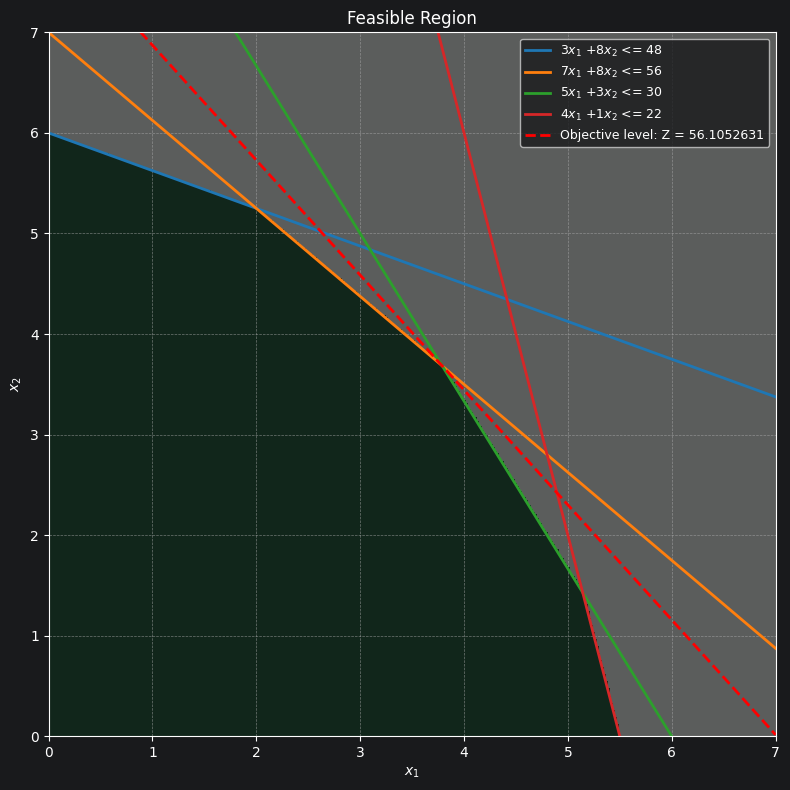

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Feasible Region'}, xlabel='$x_1$', ylabel='$x_2$'>)

In [4]:
x = PLP.LpVariable.dicts("x", indices= range(2), lowBound= 0)

model = PLP.LpProblem(
    name="Model",
    sense=PLP.LpMaximize)

# Objective
model += 8 * x[0] + 7*x[1]
# Constraints
model += 3*x[0] + 8*x[1] <= 48
model += 7*x[0] + 8*x[1] <= 56
model += 5*x[0] + 3*x[1] <= 30
model += 4*x[0] + 1*x[1] <= 22

feas = LPFeasibleRegionPlotter(None,
                               None,
                               None,
                               x1_bounds=(0,7),
                               x2_bounds=(0,7),
                               )
feas.constraints_from_model(model)
feas.plot()


## Spørgsmål 2

Problemet defineret i spørgsmål 1 løses


In [5]:
model.solve()
print("Objective value:", PLP.value(model.objective))
for v in model.variables():
    print(v.name, ":", v.varValue)

Objective value: 56.1052631
x_0 : 3.7894737
x_1 : 3.6842105


## Spørgsmål 3

Jeg finder skyggepriserne

In [6]:
# Beregninger/kode til dette spørgsmål kan skrives her
# Duals (shadow prices)
# These can be interpreted as the profit we would gain/lose for a small relaxation/restriction in the constraint
for name, constraint in model.constraints.items():
    print(name, "dual =", constraint.pi)

_C1 dual = -0.0
_C2 dual = 0.57894737
_C3 dual = 0.78947368
_C4 dual = -0.0


\newpage

# Opgave 2



## Spørgsmål 1

De brugbare heltalspunkter markeres med en rød prik

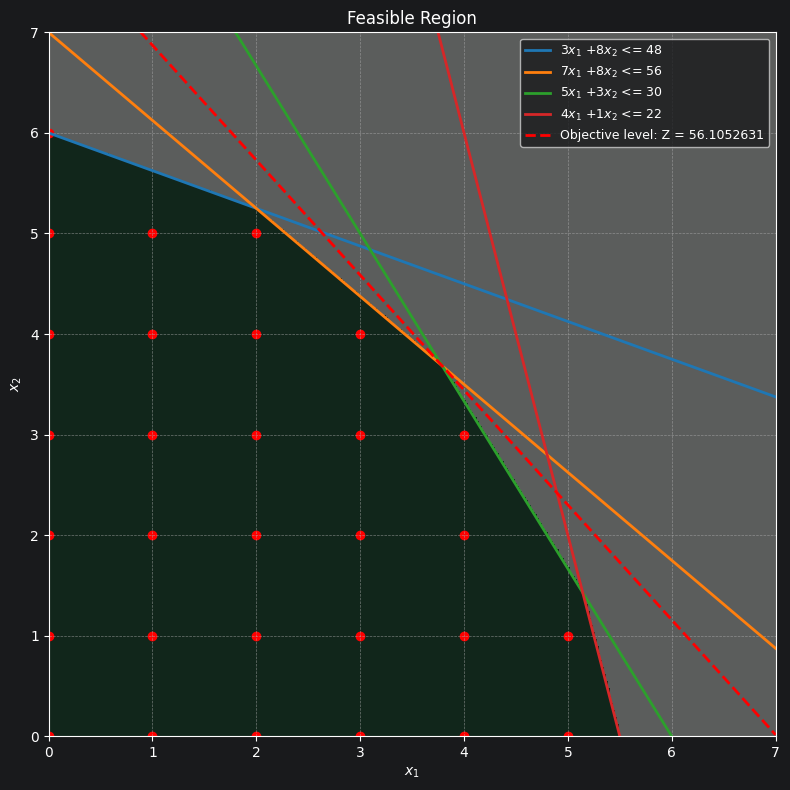

In [7]:
feas.plot(show=False)
import matplotlib.pyplot as plt
points = [(0,x2) for x2 in range(7)]
points = points + [(1,x2) for x2 in range(6)]
points = points + [(2,x2) for x2 in range(6)]
points = points + [(3,x2) for x2 in range(5)]
points = points + [(4,x2) for x2 in range(4)]
points = points + [(5,x2) for x2 in range(2)]
x,y = zip(*points)
plt.scatter(x,y, c= "red")
plt.show()


## Spørgsmål 2

Jeg har implementeret en rekursiv solver der benytter branch and bound til at løse ILP problemer ved hjælp at PULP LP problemer.

In [8]:
# Beregninger/kode til dette spørgsmål kan skrives her
import pulp as PLP
import numpy as np
from math import ceil, floor
import copy


def branch_and_bound(LPmodel, sense, best_so_far = [None], objectives = [None], problem = [0]):

    """
    :param LPmodel:
    input a Linear Programming relaxation of the ILP problem.
    Note it is import to keep track of if it is a minimization or maximization problem, as this will determine the
    branching strategy and pruning strategy.
    :return:
    Iterative Branch and Bound solution to the ILP problem.
    """
    if best_so_far[0] is None:
        if sense == "maximize":
            best_so_far[0] = -10 ** 6
        else:
            best_so_far[0] = 10 ** 6

    if sense != "maximize" and sense != "minimize":
        raise ValueError("sense must be either 'maximize' or 'minimize'")
    if sense == "maximize":
        def objective_is_not_better(obj):
            return obj < best_so_far[0]
    if sense == "minimize":
        def objective_is_not_better(obj):
            return obj > best_so_far[0]


    def is_integer_value():
        """
        :return:
        dict where keys are variable names and values are boolean values indicating whether variable is integer.
        """
        eps = 10**-4
        vars = LPmodel.variables()

        d = dict()
        # Assign boolean values to the decision variables based on whether they are integer or not
        for var in vars:
            if abs(var.varValue - ceil(var.varValue)) > eps and abs(var.varValue - floor(var.varValue)) > eps:
                d[var.name] = False
            else:
                d[var.name] = True
        return d
    print(20*"#")
    print("Problem : ", problem[0])
    print(20 * "#")
    print()
    ### Step 1 - Solve problem ###
    LPmodel.solve(PLP.PULP_CBC_CMD(msg = 0))
    obj = PLP.value(LPmodel.objective)
    ### Step 2 - Branch on non-integer decision variable
    vars = is_integer_value()
    if LPmodel.status == PLP.LpStatusInfeasible:
        print("Pruning branch, infeasible\n")
        return objectives
    if objective_is_not_better(obj):
        print("Pruning branch with objective value ", obj, " which is worse than best so far ", best_so_far[0])
        print("Decision variables: ")
        for v in LPmodel.variables():
            print(v.name, "=", v.varValue)
        print("Objective value: ", obj)
        print()
        return objectives
    if all([v for v in vars.values()]):
        print("Found feasible branch, backtracking")
        print("Decision variables: ")
        for v in LPmodel.variables():
            print(v.name, "=", v.varValue)
        print("Objective value: ", obj)
        print()
        if obj > best_so_far[0] and sense == "maximize":
            best_so_far[0] = obj
        if obj < best_so_far[0] and sense == "minimize":
            best_so_far[0] = obj
        objectives[0] = obj
        return objectives


    for name, value in vars.items():
        if value:
            continue
        else:
            branch_name = name
            branch_value = LPmodel.variablesDict()[branch_name].varValue
            break
    ### Step 3 - Create two branches and solve recursively ###
    ### Base case - All decision variables or the problem is not feasible or objective does not become better ###


    # Left branch
    left_model = copy.deepcopy(LPmodel)
    left_model += left_model.variablesDict()[branch_name] <= floor(branch_value)

    for v in LPmodel.variables():
        print(v.name, "=", v.varValue)

    print("Objective: ", obj)
    print("Adding constraint ", branch_name, " <= ", floor(branch_value), " to left branch")
    print()
    problem[0] = problem[0] + 1
    branch_and_bound(left_model, sense, best_so_far, objectives, problem)

    # Right branch
    right_model = copy.deepcopy(LPmodel)
    right_model += right_model.variablesDict()[branch_name] >= ceil(branch_value)

    print("Adding constraint ", branch_name, " >= ", ceil(branch_value), " to right branch")
    print()
    problem[0] = problem[0] + 1
    branch_and_bound(right_model, sense, best_so_far, objectives, problem)

    return best_so_far[0]


Ovenstående kode benyttes til al løse problemet. (x1, x2) angives i parentes, objekt værdi som enestående tal.

In [9]:
branch_and_bound(LPmodel = model, sense="maximize")

####################
Problem :  0
####################

x_0 = 3.7894737
x_1 = 3.6842105
Objective:  56.1052631
Adding constraint  x_0  <=  3  to left branch

####################
Problem :  1
####################

x_0 = 3.0
x_1 = 4.375
Objective:  54.625
Adding constraint  x_1  <=  4  to left branch

####################
Problem :  2
####################

Found feasible branch, backtracking
Decision variables: 
x_0 = 3.0
x_1 = 4.0
Objective value:  52.0

Adding constraint  x_1  >=  5  to right branch

####################
Problem :  3
####################

x_0 = 2.2857143
x_1 = 5.0
Objective:  53.2857144
Adding constraint  x_0  <=  2  to left branch

####################
Problem :  4
####################

x_0 = 2.0
x_1 = 5.25
Objective:  52.75
Adding constraint  x_1  <=  5  to left branch

####################
Problem :  5
####################

Pruning branch with objective value  51.0  which is worse than best so far  52.0
Decision variables: 
x_0 = 2.0
x_1 = 5.0
Objective value:  51.

53.0

## Spørgsmål 3

Modellen løses vha. PULP med heltalskrav

In [10]:
x = PLP.LpVariable.dicts("x", indices= range(2), lowBound= 0, cat= PLP.LpInteger)

model = PLP.LpProblem(
    name="Model",
    sense=PLP.LpMaximize)

# Objective
model += 8 * x[0] + 7*x[1]
# Constraints
model += 3*x[0] + 8*x[1] <= 48
model += 7*x[0] + 8*x[1] <= 56
model += 5*x[0] + 3*x[1] <= 30
model += 4*x[0] + 1*x[1] <= 22

model.solve()
print("Objective value:", PLP.value(model.objective))
for v in model.variables():
    print(v.name, ":", v.varValue)


Objective value: 53.0
x_0 : 4.0
x_1 : 3.0


\newpage

# Opgave 3

Skriv din besvarelse nedenfor.


## Spørgsmål 1

Da $\delta_i$ er en binær variabel og den vægtede sum af dem skal være mindre en given værdi $Q = 30$ og vægtene er heltallige, er det en knapsack ulighed. Dette ses i Kap10 Heltalsmodeller i uge 13 at være at opfylde kravene til en knapsack ulighed.

## Spørgsmål 2

Det følger af Kap10 Heltalsmodeller i uge 13 at $S = \{ 1,2,3 \}$ er et cover da $a(S) > 30$, da er

$$\delta_1 +\delta_2 + \delta_3  \leq |S| - 1 = 2$$
en cover ulighed.

$S_m =  \{ 1, 2 \}$ er et minimalt cover da hvis vi fjerner en vilkårlig værdi $k \in S$ fra $S$ er det ikke længere et cover. Det følger så at
$$\delta_1 + \delta_2  \leq |S| - 1 = 1$$
er en minimal cover ulighed.


In [11]:
# Beregninger/kode til dette spørgsmål kan skrives her


## Spørgsmål 3

Da et extended cover skal fremkomme fra et minimal cover hvor højresiden ikke ændres er der altså krav om at der i begrænsningen skal eksistere et minimalt cover der har kardinalitet $|S| = 3$, da det extended cover har $2$ på højresiden.

Ydermere jf. Kap10- Heltalsmodeller slide 2, skal koeffcienter for $\delta_j$ variable der tilføjes i den extended cover ulighed være større en den største koeffcient i din minimale cover ulighed. Det bemærkes at alle variable skal tilføjes i den extended cover inequality.

Dette udelukker da (1) da vi ikke kan danne en minimal cover ulighed med kardinalitet 3, hvori den største koeffcient $23$ indgår, det kan vi derimod med (2), ved at lade $S = \{1, 2, 4\}$

LP-relaksationen løses nu

In [30]:
model = PLP.LpProblem("LP", sense=PLP.LpMaximize)
deltaLP = PLP.LpVariable.dicts("deltaLP", indices= range(6), lowBound= 0, upBound= 1)

obj_coef = [17, 15 , 14 , 12, 11, 10]
coef1 = [23, 19 ,18 ,12, 7 ,5]
coef2 = [8, 11, 16, 17, 14, 12]

model += PLP.lpSum(deltaLP[i]*obj_coef[i] for i in range(6))
model += PLP.lpSum(deltaLP[i]*coef1[i] for i in range(6)) <= 30
model += PLP.lpSum(deltaLP[i]*coef2[i] for i in range(6)) <= 30

model.solve()
print("Objective value:", PLP.value(model.objective))
for v in model.variables():
    print(v.name, ":", v.varValue)



Objective value: 33.1654135
deltaLP_0 : 0.84210526
deltaLP_1 : 0.0
deltaLP_2 : 0.0
deltaLP_3 : 0.0
deltaLP_4 : 0.80451128
deltaLP_5 : 1.0


og nu med cover uligheden tilføjet

In [31]:
model += PLP.lpSum(deltaLP[i] for i in range(6)) <= 2
model.solve()
print("Objective value:", PLP.value(model.objective))
for v in model.variables():
    print(v.name, ":", v.varValue)

Objective value: 28.0
deltaLP_0 : 1.0
deltaLP_1 : 0.0
deltaLP_2 : 0.0
deltaLP_3 : 0.0
deltaLP_4 : 1.0
deltaLP_5 : 0.0


## Spørgsmål 4

_Indsæt din besvarelse her._

<!-- Billede, hvis relevant:
<img src="images/dit_billede.png" alt="Kort beskrivelse" width="600">
-->


In [ ]:
# Beregninger/kode til dette spørgsmål kan skrives her


\newpage

# Opgave 4

Skriv din besvarelse nedenfor.


## Spørgsmål 1

_Indsæt din besvarelse her._

<!-- Billede, hvis relevant:
<img src="images/dit_billede.png" alt="Kort beskrivelse" width="600">
-->


In [ ]:
# Beregninger/kode til dette spørgsmål kan skrives her


## Spørgsmål 2

_Indsæt din besvarelse her._

<!-- Billede, hvis relevant:
<img src="images/dit_billede.png" alt="Kort beskrivelse" width="600">
-->


In [ ]:
# Beregninger/kode til dette spørgsmål kan skrives her


## Spørgsmål 3

_Indsæt din besvarelse her._

<!-- Billede, hvis relevant:
<img src="images/dit_billede.png" alt="Kort beskrivelse" width="600">
-->


In [ ]:
# Beregninger/kode til dette spørgsmål kan skrives her


## Spørgsmål 4

_Indsæt din besvarelse her._

<!-- Billede, hvis relevant:
<img src="images/dit_billede.png" alt="Kort beskrivelse" width="600">
-->


In [ ]:
# Beregninger/kode til dette spørgsmål kan skrives her
